# Bangkok Rainfall Feature Analysis

This notebook analyzes `bkk_weather_lag_feature` before training a rainfall probability model.

Main goals:
- Check table size, date coverage, and missing values
- Understand rainfall class balance
- Compare weather features when rain happens vs does not happen
- Inspect time patterns by hour and month
- Find useful candidate features for ML

## 1. Setup

Install packages if needed:

```powershell
pip install pandas psycopg2-binary matplotlib seaborn
```

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "postgres",
    "user": "postgres",
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

FEATURE_TABLE = "bkk_weather_lag_feature"
TARGET = "rain_next_3h"

conn = psycopg2.connect(**DB_CONFIG)

def sql(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

## 2. Table Health

In [4]:
table_health = sql(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT grid_number) AS grid_points,
    MIN(forecast_time) AS first_time,
    MAX(forecast_time) AS last_time,
    COUNT(*) FILTER (WHERE valid_for_training = true) AS valid_training_rows
FROM {FEATURE_TABLE};
""")
table_health

,rows,grid_points,first_time,last_time,valid_training_rows
0,2387136,56,2021-08-01 00:00:00+00:00,2026-06-21 23:00:00+00:00,2337968


,date,rows,grid_points
0,2021-08-01,850,50
1,2021-08-02,1200,50
2,2021-08-03,1200,50
3,2021-08-04,1200,50
4,2021-08-05,1200,50


,date,rows,grid_points
1782,2026-06-18,1344,56
1783,2026-06-19,1344,56
1784,2026-06-20,1344,56
1785,2026-06-21,1344,56
1786,2026-06-22,392,56


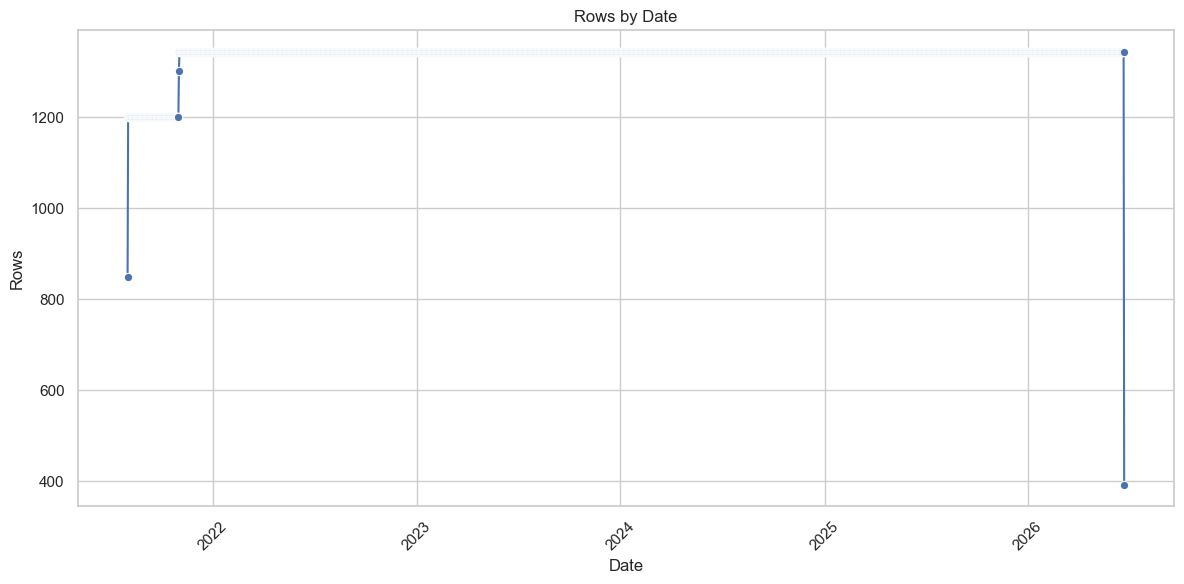

In [5]:
rows_by_day = sql(f"""
SELECT
    DATE(forecast_time) AS date,
    COUNT(*) AS rows,
    COUNT(DISTINCT grid_number) AS grid_points
FROM {FEATURE_TABLE}
GROUP BY DATE(forecast_time)
ORDER BY date;
""")

display(rows_by_day.head())
display(rows_by_day.tail())

ax = sns.lineplot(data=rows_by_day, x="date", y="rows", marker="o")
ax.set_title("Rows by Date")
ax.set_xlabel("Date")
ax.set_ylabel("Rows")
plt.xticks(rotation=45)
plt.tight_layout()

## 3. Rainfall Class Balance

This tells you how common rain is for each target window. If rain is rare, accuracy will be misleading and metrics like PR-AUC, log loss, and Brier score become more important.

In [6]:
rain_balance = sql(f"""
SELECT
    AVG(rain_next_1h::double precision) AS rain_rate_1h,
    AVG(rain_next_3h::double precision) AS rain_rate_3h,
    AVG(rain_next_6h::double precision) AS rain_rate_6h,
    SUM(rain_next_1h) AS rain_rows_1h,
    SUM(rain_next_3h) AS rain_rows_3h,
    SUM(rain_next_6h) AS rain_rows_6h,
    COUNT(*) AS rows
FROM {FEATURE_TABLE}
WHERE valid_for_training = true;
""")
rain_balance

,rain_rate_1h,rain_rate_3h,rain_rate_6h,rain_rows_1h,rain_rows_3h,rain_rows_6h,rows
0,0.219016,0.330081,0.435135,512052,771718,1017331,2337968


,target,rows
0,0,1566250
1,1,771718


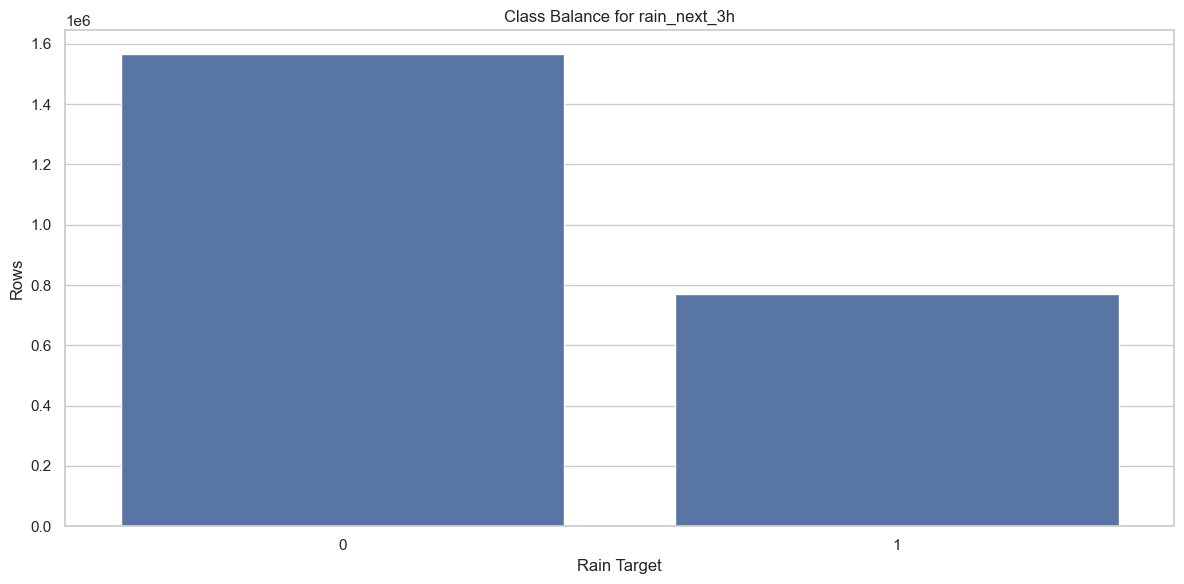

In [7]:
target_counts = sql(f"""
SELECT
    {TARGET} AS target,
    COUNT(*) AS rows
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
GROUP BY {TARGET}
ORDER BY {TARGET};
""")

display(target_counts)

ax = sns.barplot(data=target_counts, x="target", y="rows")
ax.set_title(f"Class Balance for {TARGET}")
ax.set_xlabel("Rain Target")
ax.set_ylabel("Rows")
plt.tight_layout()

## 4. Missing Values

Lag and rolling columns will naturally be missing at the beginning of each grid's time series. Future target columns will be missing at the end.

In [8]:
missing = sql(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(*) FILTER (WHERE temperature_2m IS NULL) AS temperature_2m_missing,
    COUNT(*) FILTER (WHERE relative_humidity_2m IS NULL) AS relative_humidity_2m_missing,
    COUNT(*) FILTER (WHERE precipitation IS NULL) AS precipitation_missing,
    COUNT(*) FILTER (WHERE precipitation_lag_1h IS NULL) AS precipitation_lag_1h_missing,
    COUNT(*) FILTER (WHERE precipitation_lag_6h IS NULL) AS precipitation_lag_6h_missing,
    COUNT(*) FILTER (WHERE precipitation_sum_past_24h IS NULL) AS precipitation_sum_past_24h_missing,
    COUNT(*) FILTER (WHERE precipitation_next_3h IS NULL) AS precipitation_next_3h_missing,
    COUNT(*) FILTER (WHERE valid_for_training = false) AS invalid_training_rows
FROM {FEATURE_TABLE};
""")
missing

,rows,temperature_2m_missing,relative_humidity_2m_missing,precipitation_missing,precipitation_lag_1h_missing,precipitation_lag_6h_missing,precipitation_sum_past_24h_missing,precipitation_next_3h_missing,invalid_training_rows
0,2387136,48384,48384,48384,48440,48720,47152,48328,49168


## 5. Rain vs No Rain Feature Comparison

In [9]:
feature_compare = sql(f"""
SELECT
    {TARGET} AS target,
    COUNT(*) AS rows,
    AVG(temperature_2m) AS avg_temperature_2m,
    AVG(dew_point_2m) AS avg_dew_point_2m,
    AVG(temperature_dew_point_spread) AS avg_temp_dew_spread,
    AVG(relative_humidity_2m) AS avg_relative_humidity_2m,
    AVG(cloud_cover) AS avg_cloud_cover,
    AVG(pressure_msl) AS avg_pressure_msl,
    AVG(pressure_msl_change_3h) AS avg_pressure_msl_change_3h,
    AVG(wind_speed_10m) AS avg_wind_speed_10m,
    AVG(cape) AS avg_cape,
    AVG(convective_inhibition) AS avg_convective_inhibition,
    AVG(precipitation_sum_past_3h) AS avg_precipitation_sum_past_3h,
    AVG(precipitation_sum_past_6h) AS avg_precipitation_sum_past_6h
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
GROUP BY {TARGET}
ORDER BY {TARGET};
""")
feature_compare

,target,rows,avg_temperature_2m,avg_dew_point_2m,avg_temp_dew_spread,avg_relative_humidity_2m,avg_cloud_cover,avg_pressure_msl,avg_pressure_msl_change_3h,avg_wind_speed_10m,avg_cape,avg_convective_inhibition,avg_precipitation_sum_past_3h,avg_precipitation_sum_past_6h
0,0,1566250,27.590613,21.889689,5.700925,73.119330,64.980679,1009.902593,0.050146,8.475153,956.097036,48.976083,0.244178,0.620042
1,1,771718,28.451216,24.257164,4.194052,79.255897,88.549097,1008.207557,-0.101605,8.777507,1813.904269,14.968044,1.367186,2.467259


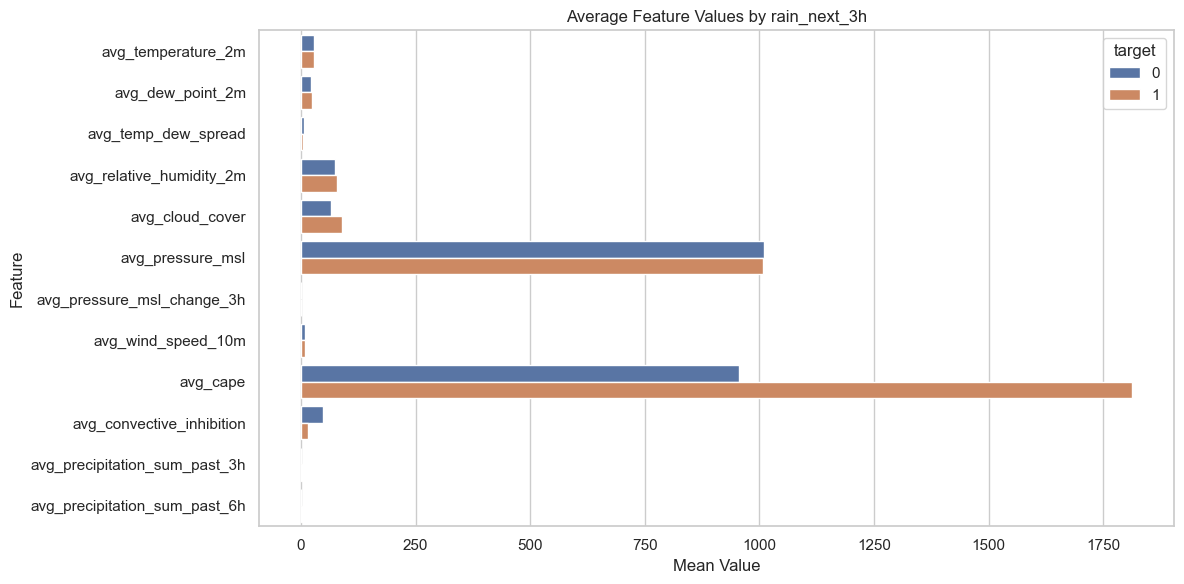

In [10]:
compare_long = feature_compare.melt(id_vars=["target", "rows"], var_name="feature", value_name="mean_value")

ax = sns.barplot(data=compare_long, x="mean_value", y="feature", hue="target")
ax.set_title(f"Average Feature Values by {TARGET}")
ax.set_xlabel("Mean Value")
ax.set_ylabel("Feature")
plt.tight_layout()

## 6. Time Patterns

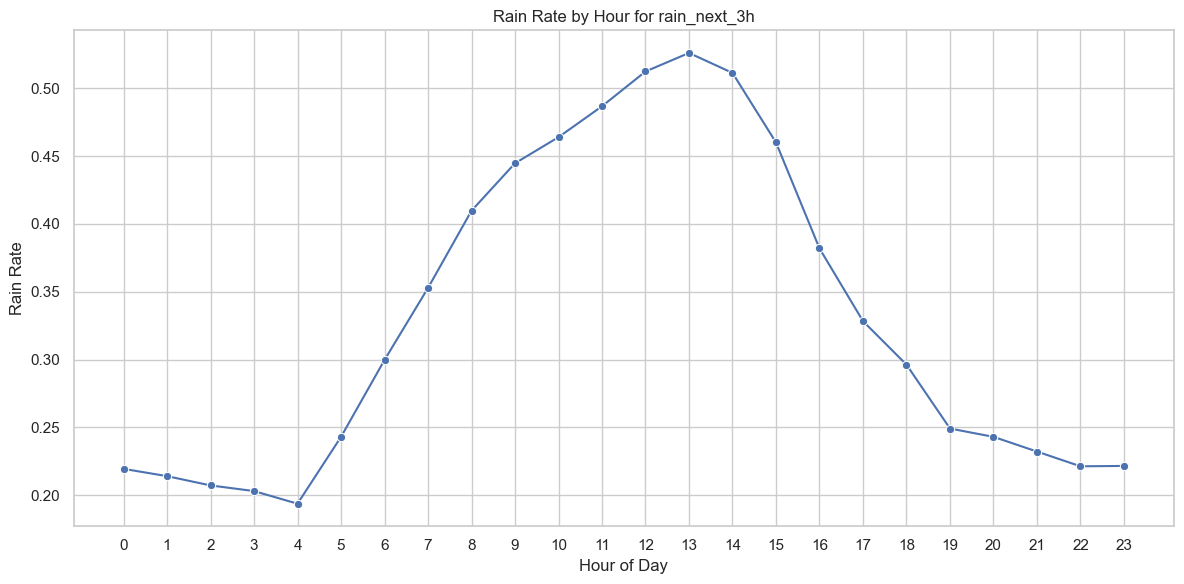

In [11]:
rain_by_hour = sql(f"""
SELECT
    hour_of_day,
    AVG({TARGET}::double precision) AS rain_rate,
    COUNT(*) AS rows
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
GROUP BY hour_of_day
ORDER BY hour_of_day;
""")

ax = sns.lineplot(data=rain_by_hour, x="hour_of_day", y="rain_rate", marker="o")
ax.set_title(f"Rain Rate by Hour for {TARGET}")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Rain Rate")
ax.set_xticks(range(0, 24))
plt.tight_layout()

,month_of_year,rain_rate,rows
0,1,0.056346,208320
1,2,0.186107,189504
2,3,0.198906,208320
3,4,0.194659,161616
4,5,0.445772,199528
5,6,0.461099,189840
6,7,0.556680,166656
7,8,0.482697,203206
8,9,0.652489,197280
9,10,0.461389,203856


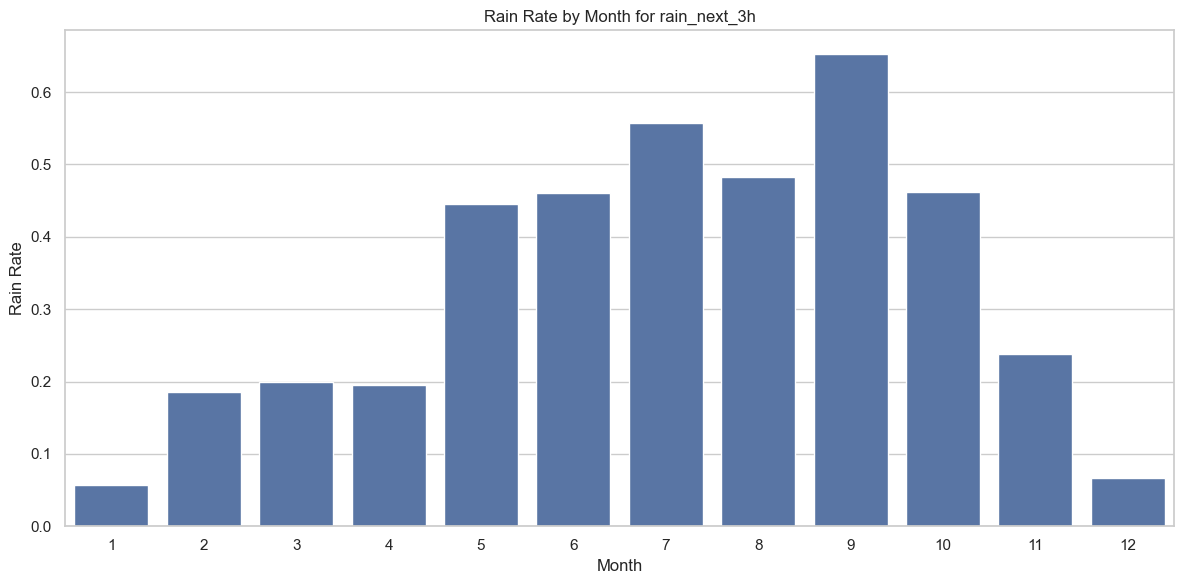

In [12]:
rain_by_month = sql(f"""
SELECT
    month_of_year,
    AVG({TARGET}::double precision) AS rain_rate,
    COUNT(*) AS rows
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
GROUP BY month_of_year
ORDER BY month_of_year;
""")

display(rain_by_month)

ax = sns.barplot(data=rain_by_month, x="month_of_year", y="rain_rate")
ax.set_title(f"Rain Rate by Month for {TARGET}")
ax.set_xlabel("Month")
ax.set_ylabel("Rain Rate")
plt.tight_layout()

## 7. Feature Correlation Sample

This samples rows from PostgreSQL to avoid loading millions of rows into memory just for correlation checks.

In [13]:
FEATURE_COLUMNS = [
    "temperature_2m",
    "dew_point_2m",
    "temperature_dew_point_spread",
    "relative_humidity_2m",
    "precipitation",
    "precipitation_lag_1h",
    "precipitation_lag_3h",
    "precipitation_sum_past_3h",
    "precipitation_sum_past_6h",
    "cloud_cover",
    "cloud_cover_avg_past_3h",
    "pressure_msl",
    "pressure_msl_change_3h",
    "surface_pressure",
    "wind_speed_10m",
    "wind_speed_10m_avg_past_3h",
    "cape",
    "cape_max_past_6h",
    "convective_inhibition",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

sample_columns = ",\n    ".join(FEATURE_COLUMNS + [TARGET])
sample_df = sql(f"""
SELECT
    {sample_columns}
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
ORDER BY random()
LIMIT 100000;
""")

sample_df.head()

,temperature_2m,dew_point_2m,temperature_dew_point_spread,relative_humidity_2m,precipitation,precipitation_lag_1h,precipitation_lag_3h,precipitation_sum_past_3h,precipitation_sum_past_6h,cloud_cover,cloud_cover_avg_past_3h,pressure_msl,pressure_msl_change_3h,surface_pressure,wind_speed_10m,wind_speed_10m_avg_past_3h,cape,cape_max_past_6h,convective_inhibition,hour_sin,hour_cos,month_sin,month_cos,rain_next_3h
0,27.0,22.7,4.3,77.0,0.1,0.0,0.0,0.0,0.0,17.0,12.666667,1016.0,3.1,1016.0,5.4,5.533333,NaN,NaN,NaN,0.707107,-0.707107,0.5,8.660254e-01,1
1,32.2,26.5,5.7,72.0,0.0,0.0,0.0,0.0,0.0,82.0,70.666667,1002.1,1.7,1001.5,14.9,16.800000,NaN,NaN,NaN,-0.866025,0.500000,0.5,-8.660254e-01,0
2,27.1,14.4,12.7,46.0,0.0,0.0,0.0,0.0,0.0,1.0,20.666667,1013.8,1.8,1013.8,6.4,10.666667,NaN,NaN,NaN,-0.866025,0.500000,0.5,8.660254e-01,0
3,24.9,23.7,1.2,93.0,0.0,0.0,0.9,0.9,4.7,99.0,100.000000,1005.3,-1.4,1005.1,5.0,7.333333,NaN,NaN,NaN,0.866025,0.500000,-0.5,-8.660254e-01,0
4,28.5,26.5,2.0,89.0,0.0,3.2,0.0,14.3,18.9,100.0,100.000000,1007.6,1.7,1007.3,4.8,5.700000,NaN,NaN,NaN,-0.866025,0.500000,-1.0,-1.836970e-16,1


,correlation_with_target
dew_point_2m,0.352163
cape_max_past_6h,0.346991
convective_inhibition,-0.318939
cape,0.311796
cloud_cover,0.301628
cloud_cover_avg_past_3h,0.301092
precipitation,0.278376
month_sin,-0.273997
precipitation_sum_past_6h,0.268783
precipitation_sum_past_3h,0.267384


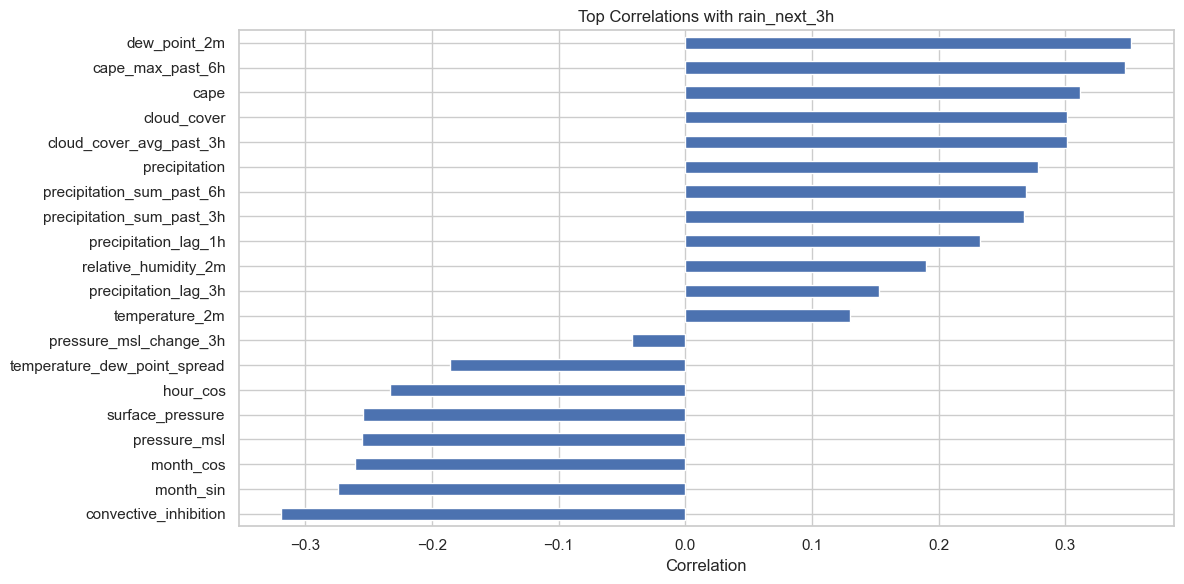

In [14]:
corr_with_target = (
    sample_df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_with_target.to_frame("correlation_with_target"))

ax = corr_with_target.head(20).sort_values().plot(kind="barh")
ax.set_title(f"Top Correlations with {TARGET}")
ax.set_xlabel("Correlation")
plt.tight_layout()

## 8. Spatial Rain Pattern by Grid Point

,grid_number,grid_row,grid_column,longitude,latitude,rain_rate,rows
0,1,1,1,100.327000,13.494,0.304840,41986
1,2,1,2,100.410224,13.494,0.295694,41986
2,3,1,3,100.493448,13.494,0.295694,41986
3,4,1,4,100.576673,13.494,0.306936,41986
4,5,1,5,100.659897,13.494,0.306936,41986


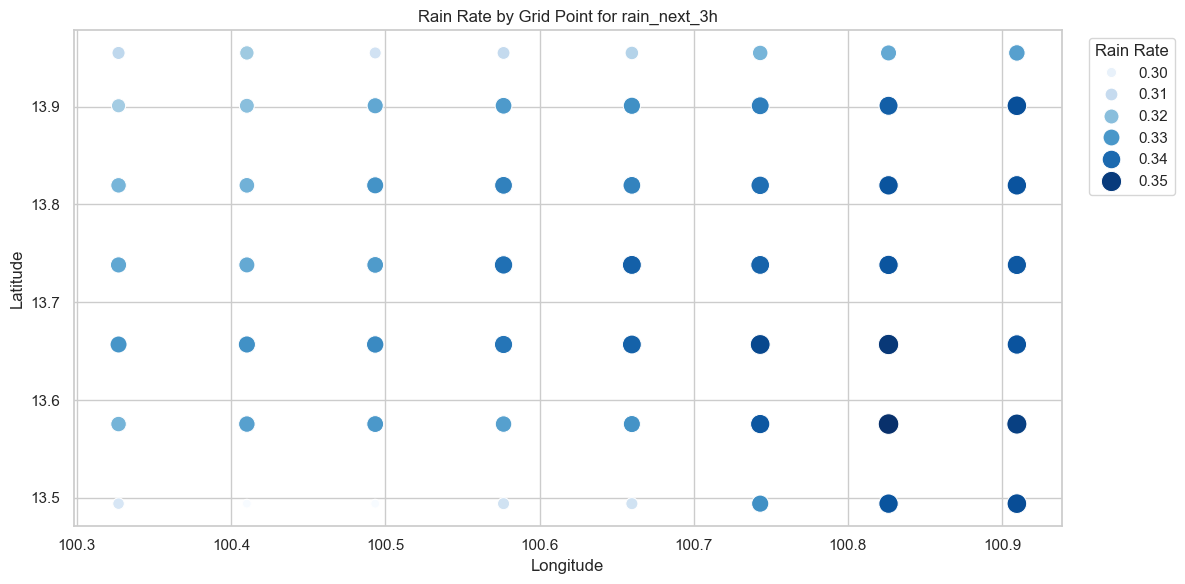

In [15]:
grid_rain = sql(f"""
SELECT
    grid_number,
    grid_row,
    grid_column,
    longitude,
    latitude,
    AVG({TARGET}::double precision) AS rain_rate,
    COUNT(*) AS rows
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
GROUP BY grid_number, grid_row, grid_column, longitude, latitude
ORDER BY grid_number;
""")

display(grid_rain.head())

ax = sns.scatterplot(
    data=grid_rain,
    x="longitude",
    y="latitude",
    hue="rain_rate",
    size="rain_rate",
    palette="Blues",
    sizes=(40, 220),
)
ax.set_title(f"Rain Rate by Grid Point for {TARGET}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend(title="Rain Rate", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 9. Suggested ML Starting Point

After reviewing the analysis above, start with `rain_next_3h` as the target and filter rows using `valid_for_training = true`.

Use a time-based split, for example:
- Oldest 70% of dates for training
- Next 15% for validation
- Newest 15% for testing

Avoid random splitting because hourly weather rows close in time are highly related.

In [16]:
training_export_query = f"""
SELECT
    grid_number,
    forecast_time,
    {', '.join(FEATURE_COLUMNS)},
    {TARGET}
FROM {FEATURE_TABLE}
WHERE valid_for_training = true
ORDER BY forecast_time, grid_number;
"""

print(training_export_query)


SELECT
    grid_number,
    forecast_time,
    temperature_2m, dew_point_2m, temperature_dew_point_spread, relative_humidity_2m, precipitation, precipitation_lag_1h, precipitation_lag_3h, precipitation_sum_past_3h, precipitation_sum_past_6h, cloud_cover, cloud_cover_avg_past_3h, pressure_msl, pressure_msl_change_3h, surface_pressure, wind_speed_10m, wind_speed_10m_avg_past_3h, cape, cape_max_past_6h, convective_inhibition, hour_sin, hour_cos, month_sin, month_cos,
    rain_next_3h
FROM bkk_weather_lag_feature
WHERE valid_for_training = true
ORDER BY forecast_time, grid_number;



In [17]:
# Run this when you are done with the notebook.
conn.close()